# Which merchants should the BNPL firm onboard?

**Summary of findings** · MAST30034 Applied Data Science, Project 2 (Buy Now, Pay Later)

A Buy Now, Pay Later (BNPL) firm can onboard at most 100 new merchants a year. We ranked all 4,026 merchants that want
to partner with it using 20 months of their transactions (28 Feb 2021 to 26 Oct 2022), consumer details, fraud
probabilities and ABS census-area data. This notebook explains which 100 we recommend and why.

It is written for non-technical readers. It only reads the results of the analysis notebooks, so it runs in seconds.
The code cells are collapsed (click the "..." to expand one) and can be skipped: every finding is stated in the text.

In [1]:
import re
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
from IPython.display import Image, Markdown, display
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

Settings and helper functions used throughout this notebook: file paths, key dates, chart colours and formatting.

In [2]:
# Files
EXTERNAL = Path("external_data")       # ABS data
CURATED = Path("curated")              # files the notebooks pass to each other
OUTPUT = Path("output")                # final rankings (CSV)
PLOTS = Path("plots")                  # charts, saved for the presentation
TRANSACTIONS_FRAUD = CURATED / "transactions_fraud.parquet"  # from fraud.ipynb
MERCHANT_DAILY = CURATED / "merchant_daily.parquet"          # from features.ipynb
SA2_SUMMARY = CURATED / "sa2_summary.parquet"                # from features.ipynb
SA2_SHAPEFILE = EXTERNAL / "shapefile" / "SA2_2021_AUST_GDA2020.shp"

SEGMENT_ORDER = ["Technology & Media", "Home & Garden", "Fashion & Personal Care", "Hobbies, Arts & Gifts",
                 "Outdoor & Auto"]  # the segments defined in features.ipynb, in a fixed order

# Chart colours
SURFACE, INK, INK_SECONDARY, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE = "#2a78d6"            # the main colour
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]  # light -> dark


def apply_style():
    """Quiet, consistent chart defaults (the same palette as etl.ipynb). Also stops Jupyter reading the dollar
    signs in tables as maths formulas."""
    pd.set_option("display.html.use_mathjax", False)
    pd.set_option("styler.html.mathjax", False)
    plt.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
        "axes.edgecolor": GRID, "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK,
        "axes.titlesize": 11, "axes.titlelocation": "left", "axes.labelsize": 10,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1, "axes.axisbelow": True,
        "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_SECONDARY, "ytick.labelcolor": INK_SECONDARY,
        "legend.frameon": False, "legend.labelcolor": INK, "font.size": 10,
        "lines.linewidth": 2, "lines.solid_capstyle": "round",
    })


def money(x, _=None):
    """$950, $12K, $3.4M (also works as an axis tick formatter)."""
    sign, x = ("-" if x < 0 else ""), abs(x)
    if x >= 1e6:
        return f"{sign}${x / 1e6:,.1f}M".replace(".0M", "M")
    if x >= 1e3:
        return f"{sign}${x / 1e3:,.0f}K"
    return f"{sign}${x:,.0f}"


def show_markdown(text):
    """Display Markdown text. Jupyter reads anything between two dollar signs ("$5 ... $10") as a maths formula, so
    each dollar sign is escaped and wrapped in its own <span> (the markdown cells do the same)."""
    text = re.sub(r"\$(\d(?:[\d,]*\d)?(?:\.\d+)?[KMB]?)", r"<span>\\$\1</span>", text)
    text = re.sub(r"(?<!\\)\$", r"<span>\\$</span>", text)
    display(Markdown(text))


def suptitle(fig, text):
    """A left-aligned title over a figure with several charts."""
    fig.suptitle(text, x=0.01, ha="left", color=INK, fontsize=13)


def save(fig, name):
    """Save a chart to plots/ for the presentation slides."""
    PLOTS.mkdir(exist_ok=True)
    fig.savefig(PLOTS / f"{name}.png", dpi=150, bbox_inches="tight")

In [3]:
apply_style()
pd.set_option("display.max_rows", 120)

ranking = pd.read_csv(OUTPUT / "merchant_ranking.csv")
ranking["category"] = ranking["category_label"]  # short names
top_100 = ranking[ranking["recommendation"] == "top 100"]
robustness = pd.read_csv(OUTPUT / "ranking_robustness.csv", index_col="variant")


def figure(name, width=900):
    """Show a chart saved by one of the analysis notebooks."""
    display(Image(filename=str(PLOTS / f"{name}.png"), width=width))


profitable = ranking.loc[ranking["expected_profit_12m"] > 0, "expected_profit_12m"].sum()
top_profit = top_100["expected_profit_12m"].sum()
loses_money = (ranking["expected_profit_12m"] <= 0).sum()
big_ticket = ranking[ranking["mean_order"] >= 2000]
modelling = robustness["top 100 unchanged"].iloc[3:]

show_markdown(f"""
## The answer in brief

- **We recommend the 100 merchants in section 5.** Together they are expected to bring the firm about
  **{money(top_profit)} of profit over the next 12 months**. That is {top_profit / profitable:.0%} of the profit available
  from every profitable merchant, from just {100 / len(ranking):.1%} of the merchants.
- **Merchants are ranked by expected profit**: the revenue the firm would earn from them (its take rate on their
  forecast sales) minus the fraud it would expect to lose through them.
- **Good merchants make lots of everyday-value sales.** The top 100 are all large, with a median of
  {top_100['transactions_12m'].median():,.0f} sales a year, and sell everyday items (median order
  ${top_100['mean_order'].median():,.0f}): gifts, craft supplies, computers, florists, tents.
- **Big-ticket merchants should be avoided.** Fraud follows the size of the purchase, and a fraudulent sale costs the
  firm the whole amount. **{(big_ticket['expected_profit_12m'] <= 0).mean():.0%} of merchants with an average order
  over $2,000 would lose the firm money**, including jewellers, antique shops, art dealers, telecom and equipment
  rental. In total, {loses_money:,} of the {len(ranking):,} merchants are expected to lose money.
- **Customer demographics and location don't separate merchants.** Every merchant's customers look like the whole
  customer base (same income, gender mix and states), and every merchant grows at about 20% a year.
- **The list is robust to our modelling choices** ({modelling.min():.0f}-{modelling.max():.0f} of the 100 stay the
  same when they change), **but it depends on who carries fraud losses**. If merchants rather than the firm bore them,
  about {100 - robustness['top 100 unchanged'].iloc[1]:.0f} of the 100 would change.
""")


## The answer in brief

- **We recommend the 100 merchants in section 5.** Together they are expected to bring the firm about
  **<span>\$20.9M</span> of profit over the next 12 months**. That is 37% of the profit available
  from every profitable merchant, from just 2.5% of the merchants.
- **Merchants are ranked by expected profit**: the revenue the firm would earn from them (its take rate on their
  forecast sales) minus the fraud it would expect to lose through them.
- **Good merchants make lots of everyday-value sales.** The top 100 are all large, with a median of
  16,266 sales a year, and sell everyday items (median order
  <span>\$249</span>): gifts, craft supplies, computers, florists, tents.
- **Big-ticket merchants should be avoided.** Fraud follows the size of the purchase, and a fraudulent sale costs the
  firm the whole amount. **99% of merchants with an average order
  over <span>\$2,000</span> would lose the firm money**, including jewellers, antique shops, art dealers, telecom and equipment
  rental. In total, 745 of the 4,026 merchants are expected to lose money.
- **Customer demographics and location don't separate merchants.** Every merchant's customers look like the whole
  customer base (same income, gender mix and states), and every merchant grows at about 20% a year.
- **The list is robust to our modelling choices** (97-100 of the 100 stay the
  same when they change), **but it depends on who carries fraud losses**. If merchants rather than the firm bore them,
  about 17 of the 100 would change.


## 1. The data and the pipeline

| Data | Rows | Used for |
|---|---|---|
| Transactions (3 snapshots, 28 Feb 2021 to 26 Oct 2022) | 14.2 million | sales, customers and order values for each merchant |
| Merchants | 4,026 | name, category, revenue level and take rate |
| Consumers | 499,999 (24,081 of them make purchases) | postcode, state and gender of each customer |
| Consumer and merchant fraud probabilities | 34,765 and 114 | how likely transactions are to be fraudulent |
| ABS: SA2 boundaries, population, income, and the mesh blocks linking postcodes to SA2s | 2,473 SA2s | where customers live, and local income and population |

The analysis runs as a pipeline of notebooks, each reading the previous one's output, so they run in this order:

| Step | Notebook | What it does |
|---|---|---|
| 1 | `etl.ipynb` | cleans and joins all the data: one row per transaction |
| 2 | `fraud.ipynb` | gives every transaction a fraud probability, using a model where the fraud files stop |
| 3 | `features.ipynb` | describes every merchant with 39 features (size, customers, order value, fraud, growth, demographics) |
| 4 | `forecast.ipynb` | forecasts every merchant's sales and fraud for the next 12 months |
| 5 | `ranking.ipynb` | ranks the merchants, applies business rules, and builds the segments and robustness checks |
| 6 | `summary.ipynb` | this notebook |

### Cleaning decisions (`etl.ipynb`)

| Step | Transactions |
|---|---|
| Raw transactions | 14,195,505 |
| Removed: merchant not in the merchant table (396 ABNs, 4.1% of transactions), so it can't be ranked | -580,830 |
| Removed: amounts below one cent (invalid) | -1,014 |
| Removed: extreme for their own merchant (outside Q1 - 3 x IQR to Q3 + 3 x IQR of that merchant's amounts) | -63,786 |
| **Clean transactions** | **13,549,875** |

- **Postcodes had lost their leading zero** (0862 stored as 862), so every NT and many ACT consumers would have
  missed their ABS data. Padding them back fixed 134,001 transactions.
- **16% of transactions come from consumers with PO-box postcodes**, which have no ABS area. They were given their
  state's income and population rather than dropped, and flagged.
- **Outliers were judged against each merchant's own sales**, not one global cut-off. A <span>\$3,000</span> sale is normal for a
  jeweller but extreme for a florist.

## 2. Fraud is the factor that matters most, and it follows purchase size

The fraud files give the probability that a consumer (or merchant) was fraudulent on a given day. Three findings
from `fraud.ipynb` shape the whole ranking:

1. **A consumer-day gets flagged when the consumer spends far more than usual.** A typical day is about <span>\$110</span>.
   Almost no day under <span>\$1,000</span> is flagged, and practically every day over <span>\$3,000</span> is. Big days carry the highest
   probabilities: over <span>\$10,000</span>, a flagged day averages a 46% chance of fraud.
2. **The files stop on 27 Feb 2022**, eight months before the transactions do, and they flag about six times fewer
   big days before 28 Aug 2021 (the start of the second data snapshot) than after. We learned what fraud looks like
   from the six months of consistent flagging, and **trained a model** to estimate fraud for the last eight
   months. On two months it never saw, it identified flagged days with a ROC AUC of 0.94 and predicted the total
   expected fraud almost exactly.
3. **Fraud costs a BNPL firm far more than it earns per sale.** On a genuine sale the firm earns its take rate
   (0.1% to 7%). On a fraudulent one it has paid the merchant and is never repaid, so it loses the whole amount.
   **A merchant is only profitable when its take rate is higher than its fraud rate.** In five big-ticket categories,
   it isn't:

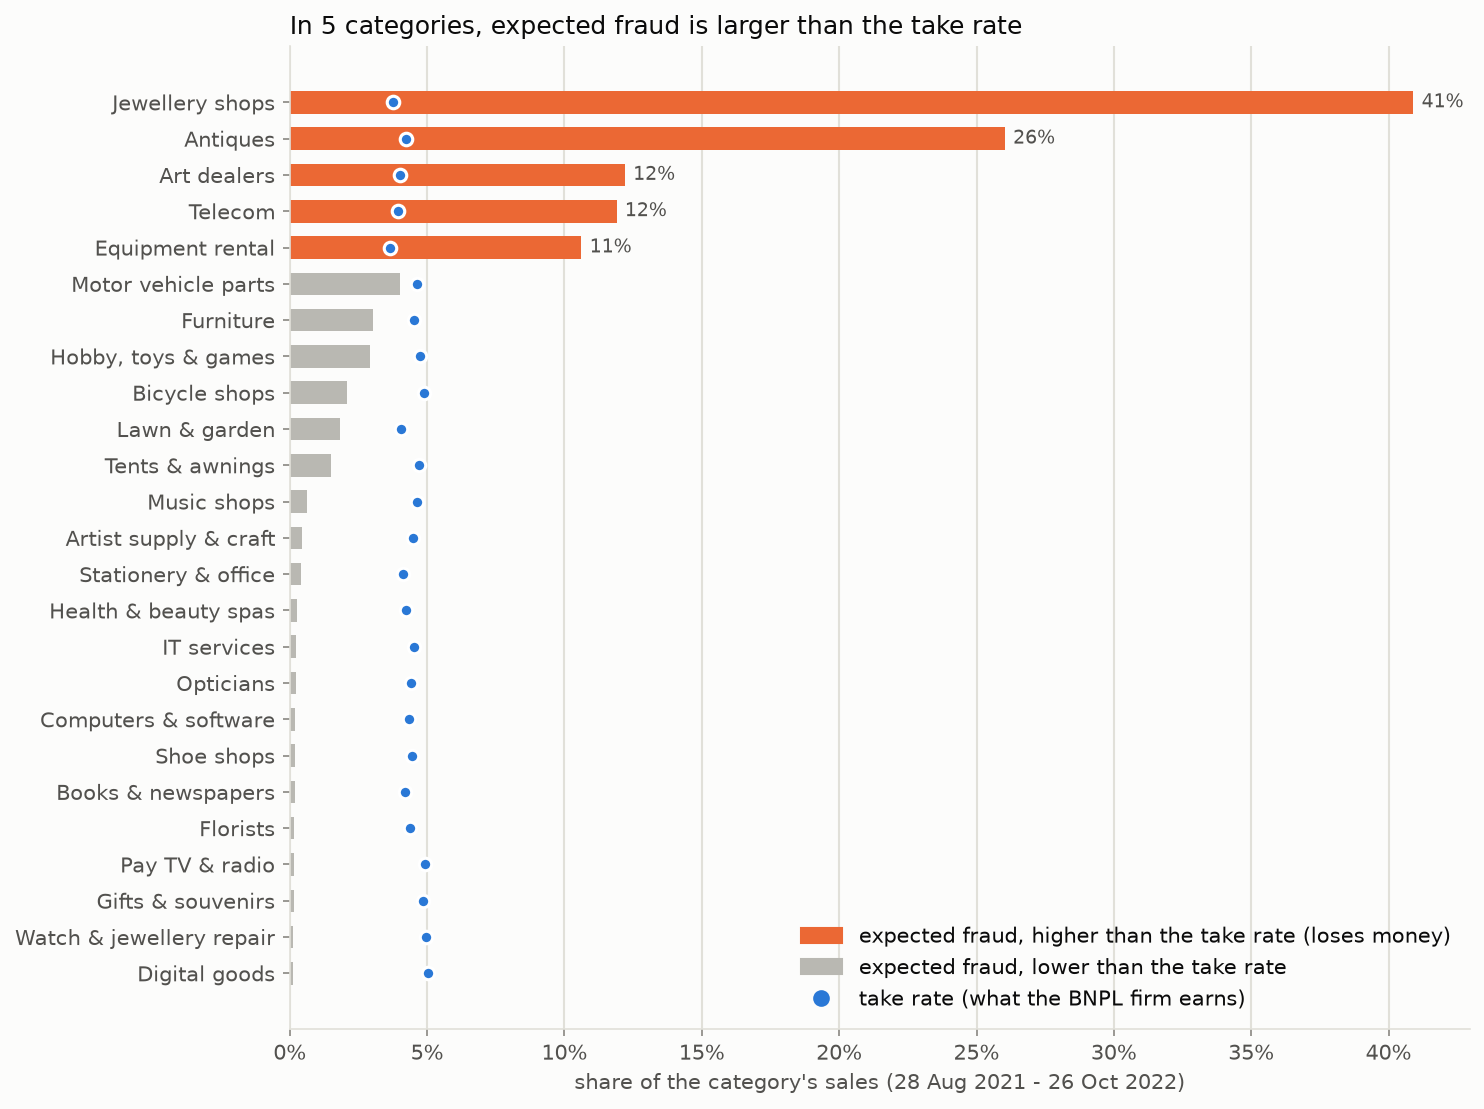

In [4]:
figure("fraud_vs_take_rate_by_category", width=760)

## 3. How the merchants are ranked

**Score = expected profit for the BNPL firm over the next 12 months:**

$$\text{expected profit} = \text{forecast sales} \times (\text{take rate} - \text{fraud rate})$$

- **Forecast sales** (`forecast.ipynb`): each merchant's last 12 months of sales, grown at the market's 20% a year.
  We tested five forecasting methods by predicting the most recent six months from the data before them. This
  simple one was the most accurate (5% error overall), and it picked 98 of the actual top 100 merchants. Using each
  merchant's own growth rate made forecasts *worse*, because every merchant grows at about the market rate.
- **Take rate**: what the merchant pays the firm (from the merchant data).
- **Fraud rate**: the merchant's expected fraud as a share of its sales, measured from 28 Aug 2021 onwards.

For example, a florist and a jeweller each selling <span>\$1M</span> a year at a 5% take rate both bring in <span>\$50,000</span> of revenue.
The florist's 0.15% fraud rate leaves about **<span>\$48,500</span>** of profit. The jeweller's 30% fraud rate means about
**-<span>\$250,000</span>**.

**Business rules.** A merchant isn't recommended, whatever its score, if it is **expected to lose money**, has made
**no sale in the last 90 days** (it may have closed), or was rated **50%+ likely to be fraudulent itself** in the
merchant fraud file.

In [5]:
funnel = ranking["not_recommended_because"].fillna("").str.split(", ").explode().value_counts().drop("", errors="ignore")
show_markdown(f"""
| | merchants |
|---|---|
| All merchants | {len(ranking):,} |
| Expected to lose money | {funnel.get('loses money', 0):,} |
| No sale in the last 90 days | {funnel.get('no sale in 90+ days', 0):,} |
| Flagged by the merchant fraud file (50%+) | {funnel.get('merchant fraud flag', 0):,} |
| **Eligible** (some fail more than one rule) | **{(ranking['recommendation'] != 'not recommended').sum():,}** |
| **Recommended: the top 100 by expected profit** | **100** |
""")


| | merchants |
|---|---|
| All merchants | 4,026 |
| Expected to lose money | 745 |
| No sale in the last 90 days | 65 |
| Flagged by the merchant fraud file (50%+) | 16 |
| **Eligible** (some fail more than one rule) | **3,268** |
| **Recommended: the top 100 by expected profit** | **100** |


## 4. What separates merchants that should and shouldn't be accepted

Each dot below is a merchant. It shows what the merchant would earn the firm (across) and how much of that
fraud would take back (up). The top 100 (blue) sit in the bottom-right corner: **the most revenue, with fraud
taking back only a few percent of it.**

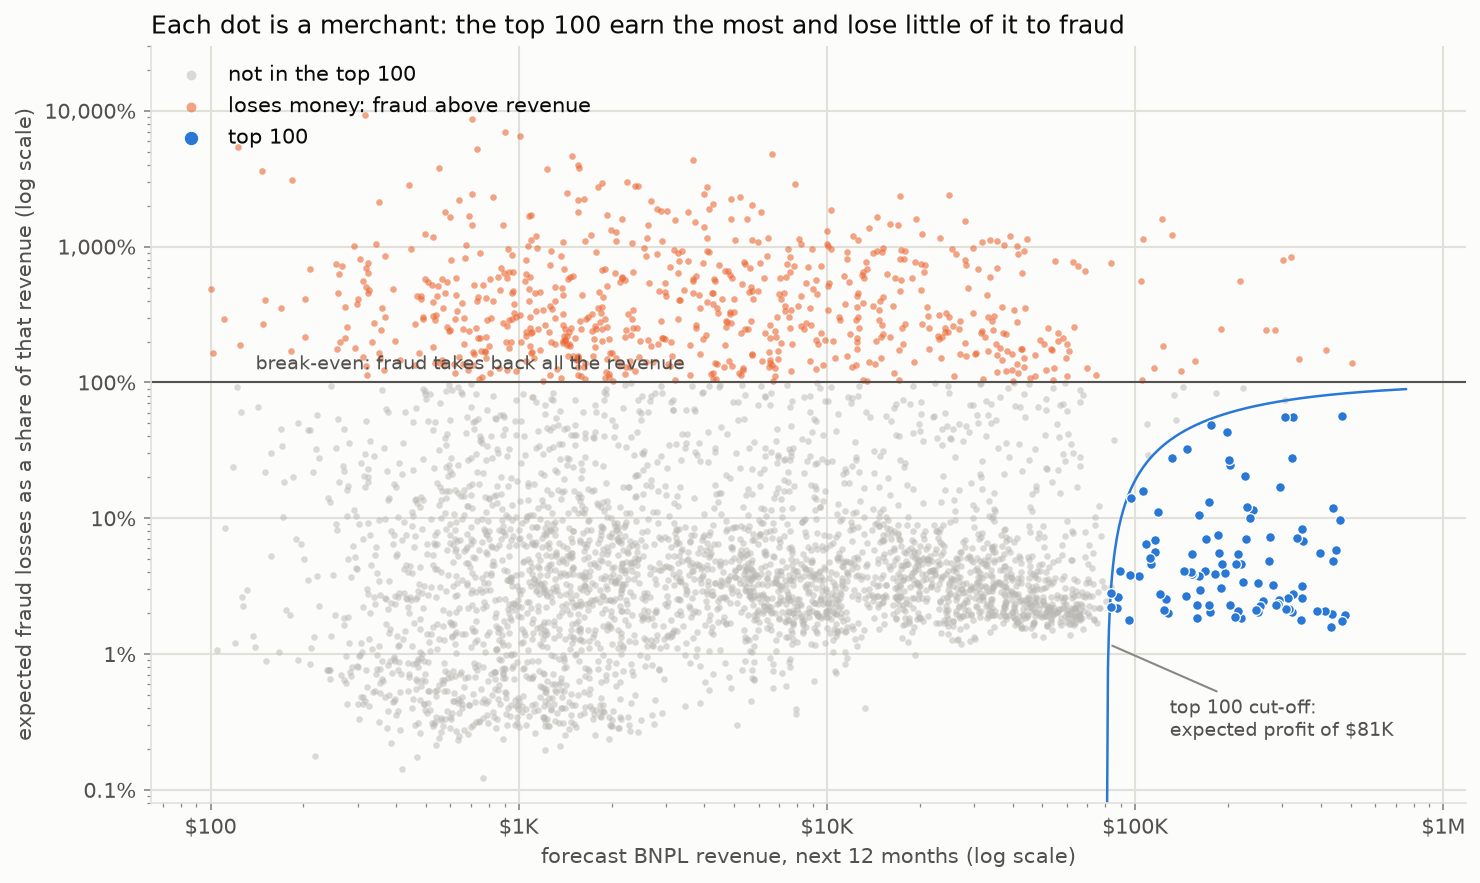

In [6]:
figure("ranking_map", width=880)

In [7]:
groups = {"top 100": ranking["recommendation"] == "top 100",
          "other eligible": ranking["recommendation"] == "eligible",
          "not recommended": ranking["recommendation"] == "not recommended"}
profile = pd.DataFrame({
    name: {
        "merchants": f"{mask.sum():,}",
        "sales in the last 12 months (median)": f"{ranking.loc[mask, 'transactions_12m'].median():,.0f}",
        "average order (median)": f"${ranking.loc[mask, 'mean_order'].median():,.0f}",
        "take rate (median)": f"{ranking.loc[mask, 'take_rate'].median():.1f}%",
        "expected fraud, % of sales (median)": f"{100 * ranking.loc[mask, 'forecast_fraud_rate'].median():.2f}%",
        "expected profit next 12 months (median)": money(ranking.loc[mask, "expected_profit_12m"].median()),
    }
    for name, mask in groups.items()
})
display(profile)

,top 100,other eligible,not recommended
merchants,100,"3,168",758
sales in the last 12 months (median),"16,266",365,24
average order (median),$249,$232,"$2,617"
take rate (median),5.6%,4.7%,3.8%
"expected fraud, % of sales (median)",0.16%,0.14%,11.74%
expected profit next 12 months (median),$183K,$3K,-$8K


**The features and heuristics that separate merchants, in order of importance:**

1. **Size.** Sales volume varies more than a thousand-fold between merchants, far more than anything else. The 100
   largest merchants earn 35% of all BNPL revenue (`features.ipynb`). Every recommended merchant made at least about
   2,200 sales in the last year.
2. **Order value, through fraud.** Big-ticket merchants attract fraud: expected fraud climbs steeply once the
   average order passes about <span>\$1,000</span> (chart below). Ranking by revenue alone would have picked 12 merchants that
   are expected to *lose* money, including the jewellers, antique dealers and telecom providers with the most sales.
3. **Take rate.** It is set by the merchant's revenue level (a = highest). Over half the top 100 are level a, and none
   are level d or e. But take rates vary about 20-fold while sales vary over a thousand-fold, so a high take rate
   can't rescue a small or fraud-prone merchant.
4. **What doesn't separate merchants:** customer income, gender, location and growth. Every large merchant's
   customers mirror the whole customer base, and every merchant grows at about 20% a year with the same Christmas
   peak (`features.ipynb`). Repeat customers differ a lot, but only because bigger merchants see the same customer
   twice more often by chance.

**Rule of thumb for screening a new applicant:** a high-volume merchant selling everyday items (orders well under
<span>\$1,000</span>) at a take rate of at least 1.5%. A big-ticket merchant should only be considered with fraud controls that
bring its fraud rate below its take rate.

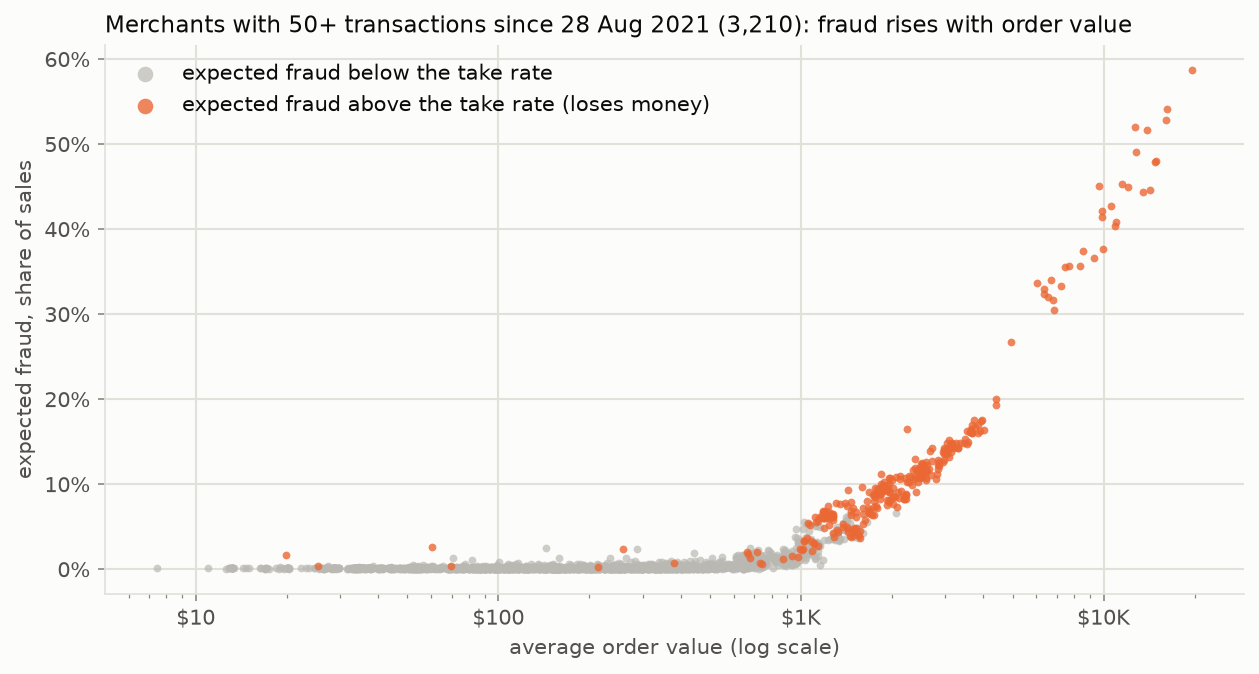

In [8]:
figure("fraud_vs_order_value", width=760)

## 5. The top 100 merchants

In [9]:
TABLE = {"rank": "rank", "merchant_name": "merchant", "merchant_abn": "ABN", "segment": "segment", "category": "category",
         "take_rate": "take rate", "forecast_revenue_12m": "forecast revenue", "forecast_fraud_rate": "expected fraud",
         "expected_profit_12m": "expected profit"}
FORMATS = {"take rate": "{:.2f}%", "forecast revenue": money, "expected fraud": "{:.2%}", "expected profit": money,
           "ABN": "{:d}"}
display(top_100[list(TABLE)].rename(columns=TABLE).set_index("rank").style.format(FORMATS))

,merchant,ABN,segment,category,take rate,forecast revenue,expected fraud,expected profit
rank,,,,,,,,
1,Orci In Consequat Corporation,32361057556,"Hobbies, Arts & Gifts",Gifts & souvenirs,6.61%,$481K,0.13%,$471K
2,Leo In Consulting,86578477987,Fashion & Personal Care,Watch & jewellery repair,6.43%,$469K,0.11%,$461K
3,Lacus Consulting,45629217853,"Hobbies, Arts & Gifts",Gifts & souvenirs,6.98%,$433K,0.11%,$426K
4,Lobortis Ultrices Company,64403598239,"Hobbies, Arts & Gifts",Music shops,6.31%,$434K,0.12%,$426K
5,Ornare Limited,96680767841,Outdoor & Auto,Motor vehicle parts,5.91%,$450K,0.34%,$424K
6,Mauris Non Institute,21439773999,Technology & Media,Pay TV & radio,6.10%,$439K,0.30%,$418K
7,Dignissim Maecenas Foundation,48534649627,Fashion & Personal Care,Opticians,6.64%,$461K,0.65%,$416K
8,Est Nunc Consulting,89726005175,Outdoor & Auto,Tents & awnings,6.01%,$414K,0.12%,$405K
9,Odio Phasellus Institute,63123845164,"Hobbies, Arts & Gifts",Artist supply & craft,6.59%,$439K,0.78%,$387K


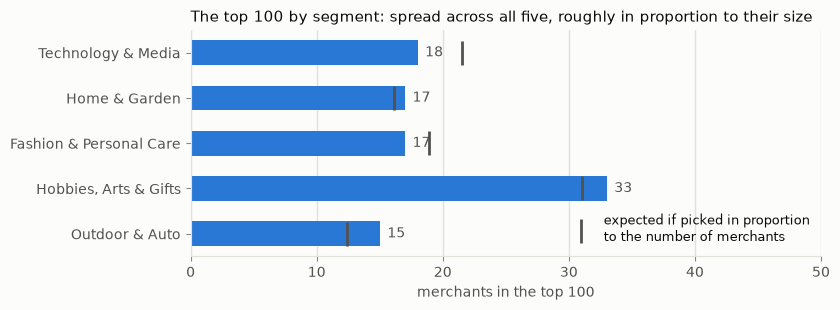


The top 100 come from 21 of the 25 categories, led by
tents & awnings (9), artist supply & craft (8), computers & software (8), watch & jewellery repair (7).
None are jewellery shops, art dealers, telecom or equipment rental. **All 100 have a high-confidence forecast** (more
than 1,000 sales in the last year), so this list doesn't depend on guesses about small merchants.


In [10]:
by_segment = (top_100["segment"].value_counts().reindex(SEGMENT_ORDER).rename("top 100").to_frame()
              .join(ranking["segment"].value_counts().rename("all merchants")))
by_segment["share of all merchants"] = by_segment["all merchants"] / by_segment["all merchants"].sum()

fig, ax = plt.subplots(figsize=(8.5, 3.2))
y = np.arange(len(by_segment))[::-1]
ax.barh(y, by_segment["top 100"], height=0.55, color=BLUE)
ax.scatter(100 * by_segment["share of all merchants"], y, color=INK_SECONDARY, marker="|", s=320, linewidth=2, zorder=3,
           label="expected if picked in proportion\nto the number of merchants")
for yi, count in zip(y, by_segment["top 100"]):
    ax.text(count + 0.6, yi, f"{count}", va="center", color=INK_SECONDARY)
ax.set_yticks(y, by_segment.index)
ax.set_xlabel("merchants in the top 100")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, 50)
ax.legend(loc="lower right", fontsize=9)
ax.set_title("The top 100 by segment: spread across all five, roughly in proportion to their size")
fig.tight_layout()
save(fig, "top_100_by_segment")
plt.show()

top_categories = top_100["category"].value_counts()
show_markdown(f"""
The top 100 come from {top_categories.size} of the 25 categories, led by
{", ".join(f"{name.lower()} ({count})" for name, count in top_categories.head(4).items())}.
None are jewellery shops, art dealers, telecom or equipment rental. **All 100 have a high-confidence forecast** (more
than 1,000 sales in the last year), so this list doesn't depend on guesses about small merchants.
""")

## 6. Top 10 merchants in each segment

The 25 categories are grouped into five segments by what the customer is buying, matching how a BNPL firm would
organise its sales teams. The same score is used in every segment, so a segment's top 10 can be compared directly
with the overall top 100. What differs is what decides the ranking. Four segments contain a big-ticket category in
which almost every merchant loses money: jewellery shops, art dealers and antiques, equipment rental, and telecom.
There, fraud decides who is excluded, and size decides the order among the rest.

Every segment has at least 15 merchants in the overall top 100, so each segment's top 10 is made up entirely of
recommended merchants (the "overall rank" column shows where each sits in the top 100).

In [11]:
segment_categories = ranking.groupby("segment")["category"].unique().map(lambda c: ", ".join(sorted(c)))
SEGMENT_TABLE = {"segment_rank": "segment rank", "rank": "overall rank", "merchant_name": "merchant", "category": "category",
                 "forecast_revenue_12m": "forecast revenue", "forecast_fraud_rate": "expected fraud",
                 "expected_profit_12m": "expected profit"}
top_10 = ranking[(ranking["recommendation"] != "not recommended") & (ranking["segment_rank"] <= 10)]
for segment in SEGMENT_ORDER:
    rows = top_10[top_10["segment"] == segment]
    show_markdown(f"#### {segment}\n*{segment_categories[segment]}*")
    display(rows[list(SEGMENT_TABLE)].rename(columns=SEGMENT_TABLE).set_index("segment rank").style.format(FORMATS))

#### Technology & Media
*Computers & software, Digital goods, IT services, Pay TV & radio, Telecom*

,overall rank,merchant,category,forecast revenue,expected fraud,expected profit
segment rank,,,,,,
1,6,Mauris Non Institute,Pay TV & radio,$439K,0.30%,$418K
2,13,Nullam Consulting,Digital goods,$345K,0.11%,$339K
3,15,Arcu Sed Eu Incorporated,IT services,$351K,0.33%,$327K
4,18,Adipiscing Elit Foundation,Computers & software,$326K,0.16%,$317K
5,22,Diam At Foundation,IT services,$308K,0.13%,$301K
6,25,Eu Placerat LLC,Computers & software,$287K,0.14%,$280K
7,29,Suspendisse Ac Associates,Digital goods,$260K,0.12%,$253K
8,30,Eleifend PC,IT services,$254K,0.13%,$249K
9,39,Nullam Enim Ltd,Computers & software,$228K,0.23%,$212K


#### Home & Garden
*Equipment rental, Florists, Furniture, Lawn & garden*

,overall rank,merchant,category,forecast revenue,expected fraud,expected profit
segment rank,,,,,,
1,19,Phasellus At Limited,Furniture,$335K,0.33%,$311K
2,21,Lorem Ipsum Sodales Industries,Florists,$312K,0.12%,$304K
3,26,Auctor Company,Florists,$279K,0.15%,$270K
4,31,Purus Gravida Sagittis Ltd,Florists,$250K,0.14%,$245K
5,33,Eu Inc.,Lawn & garden,$247K,0.13%,$241K
6,40,Semper Corp.,Florists,$216K,0.12%,$212K
7,42,Interdum Feugiat Sed Inc.,Furniture,$221K,0.15%,$210K
8,49,Erat Vitae LLP,Florists,$196K,0.12%,$188K
9,53,Phasellus Dapibus Incorporated,Furniture,$187K,0.15%,$177K


#### Fashion & Personal Care
*Health & beauty spas, Jewellery shops, Opticians, Shoe shops, Watch & jewellery repair*

,overall rank,merchant,category,forecast revenue,expected fraud,expected profit
segment rank,,,,,,
1,2,Leo In Consulting,Watch & jewellery repair,$469K,0.11%,$461K
2,7,Dignissim Maecenas Foundation,Opticians,$461K,0.65%,$416K
3,10,Gravida Mauris Incorporated,Watch & jewellery repair,$389K,0.13%,$381K
4,46,Dolor Quisque Inc.,Shoe shops,$231K,0.42%,$203K
5,48,Blandit At LLC,Shoe shops,$204K,0.13%,$199K
6,50,At Pede Inc.,Opticians,$190K,0.19%,$184K
7,56,Sociosqu Corp.,Shoe shops,$175K,0.13%,$172K
8,57,Hendrerit A Corporation,Watch & jewellery repair,$174K,0.15%,$170K
9,61,Nulla Facilisis Institute,Watch & jewellery repair,$158K,0.12%,$155K


#### Hobbies, Arts & Gifts
*Antiques, Art dealers, Artist supply & craft, Books & newspapers, Gifts & souvenirs, Hobby, toys & games, Music shops, Stationery & office*

,overall rank,merchant,category,forecast revenue,expected fraud,expected profit
segment rank,,,,,,
1,1,Orci In Consequat Corporation,Gifts & souvenirs,$481K,0.13%,$471K
2,3,Lacus Consulting,Gifts & souvenirs,$433K,0.11%,$426K
3,4,Lobortis Ultrices Company,Music shops,$434K,0.12%,$426K
4,9,Odio Phasellus Institute,Artist supply & craft,$439K,0.78%,$387K
5,11,Dictum Phasellus In Institute,Gifts & souvenirs,$397K,0.31%,$375K
6,12,Phasellus At Company,Gifts & souvenirs,$348K,0.13%,$339K
7,14,Magna Malesuada Corp.,Artist supply & craft,$348K,0.18%,$337K
8,16,Elit Sed Consequat Associates,Artist supply & craft,$349K,0.49%,$320K
9,20,Ornare Fusce Inc.,"Hobby, toys & games",$315K,0.13%,$309K


#### Outdoor & Auto
*Bicycle shops, Motor vehicle parts, Tents & awnings*

,overall rank,merchant,category,forecast revenue,expected fraud,expected profit
segment rank,,,,,,
1,5,Ornare Limited,Motor vehicle parts,$450K,0.34%,$424K
2,8,Est Nunc Consulting,Tents & awnings,$414K,0.12%,$405K
3,17,Non Vestibulum Industries,Tents & awnings,$323K,0.12%,$317K
4,24,Magna Praesent PC,Motor vehicle parts,$290K,0.16%,$283K
5,32,Luctus Et Incorporated,Tents & awnings,$295K,0.97%,$245K
6,44,Etiam Bibendum Industries,Tents & awnings,$468K,3.56%,$204K
7,47,Suspendisse Non Leo PC,Motor vehicle parts,$212K,0.14%,$202K
8,54,Sit Amet PC,Motor vehicle parts,$181K,0.14%,$174K
9,58,Pede Nonummy Corp.,Tents & awnings,$168K,0.12%,$161K


## 7. Interesting merchants

The spec asks about a few kinds of merchant in particular.

In [12]:
few_big = ranking[(ranking["customers_12m"] < 500) & (ranking["mean_order"] >= 2000)]
many_fraud = ranking[(ranking["customers_12m"] >= 1000) & (ranking["expected_profit_12m"] <= 0)]
new = ranking[ranking["limited_history"]]
watch = top_100[top_100["max_merchant_fraud_probability"].notna()]

# the days the merchant fraud file flagged for the watch-list merchants, against their usual (median) day of sales
flagged_days = (ds.dataset(TRANSACTIONS_FRAUD).to_table(columns=["merchant_abn", "order_datetime"],
                                                        filter=ds.field("merchant_fraud_probability").is_valid())
                .to_pandas().drop_duplicates())
merchant_days = pd.read_parquet(MERCHANT_DAILY, columns=["merchant_abn", "order_datetime", "sales"])
usual_day = merchant_days.groupby("merchant_abn")["sales"].median()
watch_days = flagged_days[flagged_days["merchant_abn"].isin(watch["merchant_abn"])].merge(
    merchant_days, on=["merchant_abn", "order_datetime"])
watch_days["vs_usual"] = watch_days["sales"] / watch_days["merchant_abn"].map(usual_day)
INTERESTING = {"rank": "rank", "merchant_name": "merchant", "category": "category", "customers_12m": "customers",
               "mean_order": "average order", "take_rate": "take rate", "forecast_fraud_rate": "expected fraud",
               "expected_profit_12m": "expected profit"}
STYLE = {**FORMATS, "average order": "${:,.0f}", "customers": "{:,.0f}"}

show_markdown(f"""
### A small customer base that makes large purchases

**{len(few_big):,} merchants** have fewer than 500 customers a year but an average order of $2,000 or more.
They look attractive, with high sales per customer, but **{(few_big['expected_profit_12m'] <= 0).mean():.0%} of them
are expected to lose the firm money**. Large purchases are exactly what the fraud files flag. The five with the most
revenue:
""")
display(few_big.nlargest(5, "forecast_revenue_12m")[list(INTERESTING)].rename(columns=INTERESTING)
        .set_index("rank").style.format(STYLE))

show_markdown(f"""
### A large customer base that is prone to fraud

**{len(many_fraud)} merchants** with 1,000+ customers a year are still expected to lose money. They sell mid-to-high
value items (telecom, art, furniture, garden supplies, motor vehicle parts), where fraud outweighs a normal take rate.
One sells everyday items but has a take rate of just 0.18%, so even its tiny fraud rate wipes out its revenue.
""")
display(many_fraud.sort_values("customers_12m", ascending=False)[list(INTERESTING)].rename(columns=INTERESTING)
        .set_index("rank").style.format(STYLE))

show_markdown(f"""
### New merchants with little information

**{len(new)} merchants** made their first sale less than a year before the data ends, and they have only 1 to
{new['transactions_12m'].max():.0f} sales each. Their forecasts are scaled up to a full year and marked as low
confidence. All of them sell big-ticket items ({", ".join(new['category'].value_counts().index.str.lower())}), and their
few sales are mostly expected to be fraudulent (median expected fraud {new['forecast_fraud_rate'].median():.0%}).
**None should be onboarded now.** They should be re-assessed once they have a year of sales.

### A watch list inside the top 100

**{len(watch)} of the top 100** appear in the merchant fraud file, each on 1 to 3 days with a probability of about
{watch['max_merchant_fraud_probability'].min():.0%}-{watch['max_merchant_fraud_probability'].max():.0%} (below the 50%
exclusion rule). **All {len(watch_days)} flagged days fall between {watch_days['order_datetime'].min():%d} and
{watch_days['order_datetime'].max():%d %b %Y}**, the Black Friday weekend, when these merchants sold
{watch_days['vs_usual'].min():.1f} to {watch_days['vs_usual'].max():.1f} times their usual daily amount. The flags look
like a reaction to a sales spike rather than to fraud. These merchants stay recommended, but the firm should review
those days before signing them.
""")


### A small customer base that makes large purchases

**481 merchants** have fewer than 500 customers a year but an average order of <span>\$2,000</span> or more.
They look attractive, with high sales per customer, but **99% of them
are expected to lose the firm money**. Large purchases are exactly what the fraud files flag. The five with the most
revenue:


,merchant,category,customers,average order,take rate,expected fraud,expected profit
rank,,,,,,,
4023,Ligula Elit Pretium Foundation,Antiques,112,"$19,627",4.82%,58.73%,-$1.5M
4024,Pharetra Quisque Company,Jewellery shops,374,"$9,900",2.62%,42.12%,-$1.8M
4022,Odio Incorporated,Jewellery shops,117,"$16,046",4.62%,52.78%,-$1.1M
4019,Mi Corporation,Antiques,66,"$13,928",6.77%,51.61%,-$551K
3753,In Scelerisque Inc.,Furniture,380,"$2,229",6.91%,8.78%,-$19K



### A large customer base that is prone to fraud

**13 merchants** with 1,000+ customers a year are still expected to lose money. They sell mid-to-high
value items (telecom, art, furniture, garden supplies, motor vehicle parts), where fraud outweighs a normal take rate.
One sells everyday items but has a take rate of just 0.18%, so even its tiny fraud rate wipes out its revenue.


,merchant,category,customers,average order,take rate,expected fraud,expected profit
rank,,,,,,,
3999,Nec Incorporated,Telecom,"3,122","$1,839",5.55%,9.70%,-$311K
3955,Torquent Per Inc.,Lawn & garden,"2,965","$1,313",2.45%,4.56%,-$106K
3985,Amet Risus Inc.,Furniture,"2,847","$2,017",6.82%,9.56%,-$203K
3978,Magna Sed Industries,Art dealers,"2,470","$1,793",5.96%,8.86%,-$165K
3924,Ac Urna Consulting,Art dealers,"2,458","$1,194",4.25%,6.14%,-$69K
3821,Nam Ligula Elit Foundation,Lawn & garden,"2,355","$1,324",3.58%,4.37%,-$31K
4014,Semper Auctor PC,Motor vehicle parts,"2,306","$2,132",4.52%,10.98%,-$406K
3322,Felis Limited,Furniture,"2,001",$214,0.18%,0.22%,-$205
4021,Pede Cras Vulputate Ltd,Telecom,"1,510","$3,718",3.15%,17.52%,-$997K



### New merchants with little information

**22 merchants** made their first sale less than a year before the data ends, and they have only 1 to
6 sales each. Their forecasts are scaled up to a full year and marked as low
confidence. All of them sell big-ticket items (antiques, jewellery shops, telecom), and their
few sales are mostly expected to be fraudulent (median expected fraud 43%).
**None should be onboarded now.** They should be re-assessed once they have a year of sales.

### A watch list inside the top 100

**12 of the top 100** appear in the merchant fraud file, each on 1 to 3 days with a probability of about
29%-33% (below the 50%
exclusion rule). **All 20 flagged days fall between 26 and
29 Nov 2021**, the Black Friday weekend, when these merchants sold
2.6 to 3.2 times their usual daily amount. The flags look
like a reaction to a sales spike rather than to fraud. These merchants stay recommended, but the firm should review
those days before signing them.


## 8. Where the customers are

The maps group consumers by the ABS area (SA3) of their postcode. Consumers with PO-box postcodes (16%) can't be
placed and are left out.

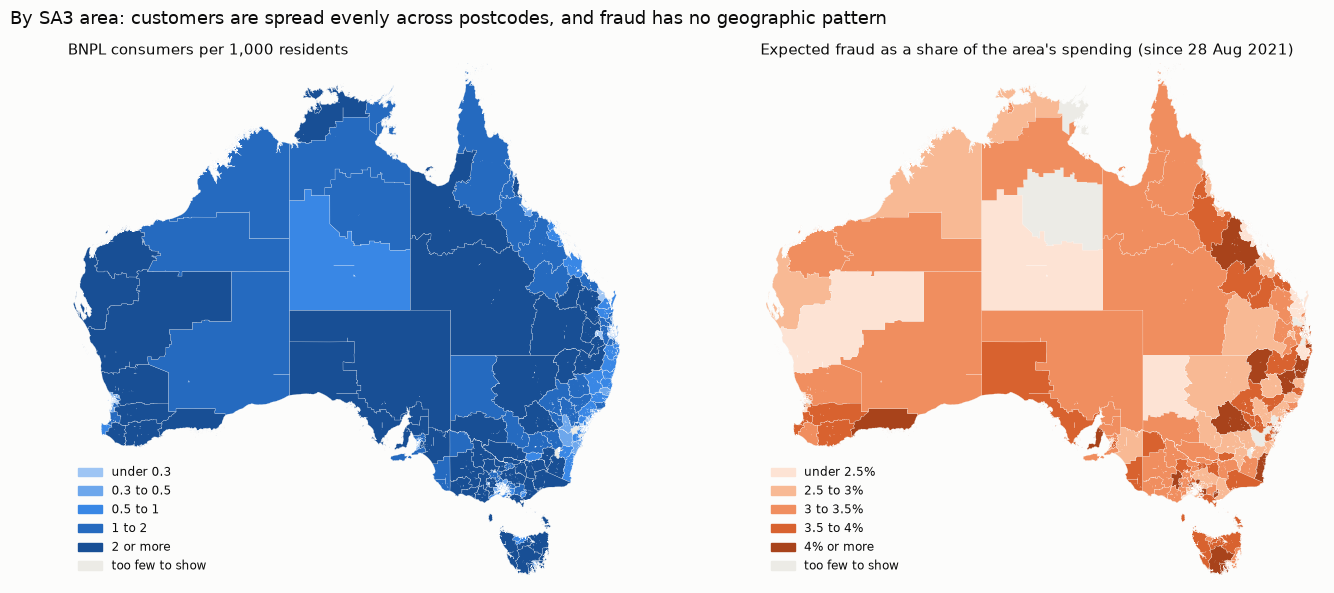

,consumers,population,"consumers per 1,000 residents",expected fraud (% of spending)
region,,,,
capital cities,"7,764","17,991,281",0.43,3.24
rest of Australia,"12,347","8,657,597",1.43,3.36


In [13]:
areas = gpd.read_file(SA2_SHAPEFILE, columns=["SA2_CODE21", "SA3_CODE21", "SA3_NAME21", "GCC_NAME21", "geometry"])
areas = areas[areas.geometry.notna()]
areas["geometry"] = areas.geometry.simplify(0.002, preserve_topology=True)  # lighter outlines, faster to draw
areas = areas.merge(pd.read_parquet(SA2_SUMMARY), left_on="SA2_CODE21", right_on="sa2_code", how="left")
sa3 = areas.dissolve(by="SA3_CODE21", aggfunc={"SA3_NAME21": "first", "GCC_NAME21": "first", "population": "sum",
                                                "consumers": "sum", "sales_since_snapshot": "sum",
                                                "expected_fraud_since_snapshot": "sum"})
sa3["consumers_per_1000"] = 1000 * sa3["consumers"] / sa3["population"].where(sa3["population"] >= 1000)
sa3["fraud_rate"] = sa3["expected_fraud_since_snapshot"] / sa3["sales_since_snapshot"].where(sa3["consumers"] >= 20)


def choropleth(ax, column, bins, labels, colors, title):
    data = sa3[sa3[column].notna()]
    norm = BoundaryNorm(bins, len(colors))
    sa3.plot(ax=ax, color="#ecebe6", linewidth=0)  # areas without enough data
    data.plot(ax=ax, column=column, cmap=ListedColormap(colors), norm=norm, linewidth=0.15, edgecolor="white")
    ax.set_xlim(112.5, 154.5)
    ax.set_ylim(-44.2, -9.5)
    ax.set_axis_off()
    ax.set_title(title)
    handles = [Patch(color=c, label=l) for c, l in zip(colors, labels)] + [Patch(color="#ecebe6", label="too few to show")]
    ax.legend(handles=handles, loc="lower left", fontsize=8.5)


fig, (ax_customers, ax_fraud) = plt.subplots(1, 2, figsize=(14, 6))
choropleth(ax_customers, "consumers_per_1000", [0, 0.3, 0.5, 1, 2, 100],
           ["under 0.3", "0.3 to 0.5", "0.5 to 1", "1 to 2", "2 or more"], BLUE_RAMP[1::1][:5],
           "BNPL consumers per 1,000 residents")
choropleth(ax_fraud, "fraud_rate", [0, 0.025, 0.03, 0.035, 0.04, 1],
           ["under 2.5%", "2.5 to 3%", "3 to 3.5%", "3.5 to 4%", "4% or more"],
           ["#fde3d4", "#f8b994", "#f08e5f", "#d8622f", "#a8431b"],
           "Expected fraud as a share of the area's spending (since 28 Aug 2021)")
suptitle(fig, "By SA3 area: customers are spread evenly across postcodes, and fraud has no geographic pattern")
fig.tight_layout()
save(fig, "maps")
plt.show()

region = sa3.assign(region=np.where(sa3["GCC_NAME21"].str.startswith(("Greater", "Australian Capital")),
                                     "capital cities", "rest of Australia"))
region = region.groupby("region")[["consumers", "population", "expected_fraud_since_snapshot", "sales_since_snapshot"]].sum()
region["consumers per 1,000 residents"] = 1000 * region["consumers"] / region["population"]
region["expected fraud (% of spending)"] = 100 * region["expected_fraud_since_snapshot"] / region["sales_since_snapshot"]
display(region[["consumers", "population", "consumers per 1,000 residents", "expected fraud (% of spending)"]]
        .style.format({"consumers": "{:,.0f}", "population": "{:,.0f}", "consumers per 1,000 residents": "{:.2f}",
                       "expected fraud (% of spending)": "{:.2f}"}))

- **Customers are spread almost evenly across postcodes, not across people.** Regional areas have several times as
  many BNPL consumers per resident as the capital cities. For the firm, this means its customer base is far more
  regional than Australia's population, which may be worth knowing for marketing. It is also a sign of how the
  synthetic data was generated.
- **Fraud shows no geographic pattern.** It is about the same share of spending in the cities and the regions. When
  consumers were shuffled between areas at random, the areas differed just as much as the real ones do
  (`features.ipynb`), and fraud isn't related to local income.
- **Location doesn't help choose merchants.** Every merchant's customers come from all eight states in the same
  proportions (`features.ipynb`). The data has no merchant locations, so merchants can't be compared by where
  they are.

## 9. How much to trust the ranking

In [14]:
display(robustness.style.format({"top 100 unchanged": "{:.0f}", "rank correlation with the main ranking": "{:.3f}"}))

,top 100 unchanged,rank correlation with the main ranking
variant,,
the firm loses half a fraudulent sale (λ = 0.5),94,0.951
fraud only costs the take rate (λ = 0),83,0.698
fraud ignored (rank by revenue),82,0.666
fraud rate from the fraud files only (no model),97,0.992
fraud rate including the under-flagged first snapshot,98,0.986
past revenue instead of the forecast,100,1.000


- **The modelling choices barely matter.** Using past revenue instead of the forecast, or fraud from the fraud files
  instead of the model, leaves 97 to 100 of the top 100 unchanged.
- **The fraud assumption matters.** We assumed the firm bears the full cost of a fraudulent sale, which is the usual
  BNPL model. If merchants bore half, 94 of the 100 would stay. If fraud cost the firm nothing beyond the lost fee,
  only 83 would, and the list would then include merchants that lose money under our assumption. **The firm should
  confirm its fraud-liability terms before finalising the list.**

## 10. Assumptions, limitations and issues

**Assumptions**
- A transaction not listed in the fraud files is not fraud (the spec calls them "a delta file of transactions to be
  treated as fraud"). A listed probability is used as an expected value rather than a yes/no label.
- The firm loses the full value of a fraudulent sale. Sensitivity to this is shown above.
- The next 12 months look like the last 12, grown at the market's 20% a year, with the same take rates and fraud
  behaviour.
- Profit is revenue minus fraud only. The data has nothing on operating costs or on genuine customers who fail to
  repay (credit losses), so neither is included.
- Each postcode is placed in the SA2 that holds most of its homes. PO-box postcodes get state-level income and
  population.

**Limitations**
- The data is synthetic. Customers choose merchants regardless of where they live or what they earn, which is why
  demographics can't separate merchants. Real data may well show differences.
- There are no merchant locations, so "merchant location" could only be studied through where customers live.
- Fraud information stops eight months before the transactions do, and its flagging changed on 28 Aug 2021. Fraud
  after 27 Feb 2022 is a model estimate, and merchant-level fraud can't be estimated for that period (too few
  examples to model).
- Forecasts for small and new merchants are uncertain. They're marked `low` confidence, but none of them are near the
  top 100.

**Issues we ran into**
- The third transaction snapshot is labelled as ending on 28 Aug 2022 but runs to 26 Oct 2022. The extra rows look
  genuine and were kept.
- Merchant tags mixed brackets and capitalisation and contained typos, so they needed careful parsing. Postcodes had
  lost leading zeros. The consumer fraud file had duplicate rows that would have double-counted transactions.
- pandas 3 and PySpark 4.2 don't yet convert text columns between each other reliably, so data moves between them
  through parquet files. Holding millions of consumer-days in memory next to Spark crashed the fraud model, which
  now loads one month at a time.

## Reproducing these results

Run the notebooks in the order of the table in section 1, from `etl.ipynb` to this one. Besides the packages
`etl.ipynb` uses, they need scikit-learn, scipy and geopandas (`pip install scikit-learn scipy geopandas`).
Every number and chart in this notebook comes from the files in `output/`, `curated/` and `plots/` that the
notebooks write.